## Projeto do Bootcamp Avanti - Machine Learning

🔹 Projeto 03

📌 Assunto: Classificação de lesões em folhas de feijão

🔗 Dataset: https://www.kaggle.com/datasets/marquis03/bean-leaf-lesions-classification


### Participantes:
Cristiane Santos da Cunha

Eric Gabriel Aguiar de Alencar

Fabrício Almeida Santos

Ian Silva Nogueira

Jaime Teixeira de Araújo Júnior

Juliana Gonçalves Câmara

### ATIVIDADE-04-ETAPA-01
#### Objetivo: Apresentar informações do dataset





#### Baixar dataset do Kaggle

In [3]:
!pip install opendatasets
!pip install pandas
!pip install imagehash

In [4]:
import opendatasets as od
import pandas as pd

dataset_path = od.download("https://www.kaggle.com/datasets/marquis03/bean-leaf-lesions-classification")



Skipping, found downloaded files in "./bean-leaf-lesions-classification" (use force=True to force download)


In [5]:
# IMPORTAÇÕES

import pandas as pd
import os
import cv2
import imagehash
import matplotlib.pyplot as plt
%matplotlib inline
import random
import shutil


In [6]:
!ls

bean-leaf-lesions-classification  sample_data


### Criar um Dataframe com os metadados das imagens

In [7]:
root_dir = './bean-leaf-lesions-classification'

#### Separação das imagens para treinamento, teste e validação


In [10]:
# estrutura do data set

print(os.listdir("./bean-leaf-lesions-classification"))

['classname.txt', 'train.csv', 'train', 'val.csv', 'val']


In [15]:
# Criação da pasta teste
train_dir = "./bean-leaf-lesions-classification/train"
test_dir = "./bean-leaf-lesions-classification/test"
os.makedirs(test_dir, exist_ok=True)

In [16]:
# Divisão das imagens entre treinamento e 15% para teste

NUM_TESTE = 154

# -------------------------------------------------------------------
# 1. Devolve todas as imagens de TESTE para TREINAMENTO
# -------------------------------------------------------------------

for classe in os.listdir(test_dir):

    pasta_test = os.path.join(test_dir, classe)
    pasta_train = os.path.join(train_dir, classe)

    if not os.path.isdir(pasta_test):
        continue

    os.makedirs(pasta_train, exist_ok=True)

    for imagem in os.listdir(pasta_test):

        origem = os.path.join(pasta_test, imagem)
        destino = os.path.join(pasta_train, imagem)

        shutil.move(origem, destino)

# -------------------------------------------------------------------
# 2. Lista todas as imagens do treinamento
# -------------------------------------------------------------------

todas_imagens = []

for classe in os.listdir(train_dir):

    pasta_train = os.path.join(train_dir, classe)

    if not os.path.isdir(pasta_train):
        continue

    for imagem in os.listdir(pasta_train):

        todas_imagens.append((classe, imagem))

# -------------------------------------------------------------------
# 3. Sorteia 154 imagens
# -------------------------------------------------------------------

imagens_teste = random.sample(todas_imagens, NUM_TESTE)

# -------------------------------------------------------------------
# 4. Move somente as 154 imagens sorteadas para TESTE
# -------------------------------------------------------------------

for classe, imagem in imagens_teste:

    origem = os.path.join(train_dir, classe, imagem)

    pasta_test = os.path.join(test_dir, classe)
    os.makedirs(pasta_test, exist_ok=True)

    destino = os.path.join(pasta_test, imagem)

    shutil.move(origem, destino)

print(f"{NUM_TESTE} imagens movidas para TESTE com sucesso.")

154 imagens movidas para TESTE com sucesso.


In [17]:
train_df = pd.read_csv("./bean-leaf-lesions-classification/train.csv")

train_df.head()

,image:FILE,category
0,train/healthy/healthy_train.98.jpg,0
1,train/healthy/healthy_train.148.jpg,0
2,train/healthy/healthy_train.306.jpg,0
3,train/healthy/healthy_train.305.jpg,0
4,train/healthy/healthy_train.40.jpg,0


In [18]:
print(train_df.columns)

Index(['image:FILE', 'category'], dtype='object')


In [19]:
# Validação

val_df = pd.read_csv("./bean-leaf-lesions-classification/val.csv")

imagens_csv = set(val_df["image:FILE"])
imagens_pasta = set()

val_dir = "./bean-leaf-lesions-classification/val"

for classe in os.listdir(val_dir):
    pasta = os.path.join(val_dir, classe)

    if os.path.isdir(pasta):
        for img in os.listdir(pasta):
            imagens_pasta.add(img)

faltando = imagens_csv - imagens_pasta
extras = imagens_pasta - imagens_csv

print(f"Imagens listadas no CSV: {len(imagens_csv)}")
print(f"Imagens encontradas na pasta: {len(imagens_pasta)}")
print(f"Imagens no CSV e ausentes na pasta: {len(faltando)}")
print(f"Imagens na pasta e ausentes no CSV: {len(extras)}")

Imagens listadas no CSV: 133
Imagens encontradas na pasta: 133
Imagens no CSV e ausentes na pasta: 133
Imagens na pasta e ausentes no CSV: 133


In [20]:
# Ler o CSV
train_df = pd.read_csv("./bean-leaf-lesions-classification/train.csv")

# Imagens listadas no CSV
imagens_csv = set(train_df["image:FILE"])

# Imagens existentes na pasta
imagens_pasta = set()

train_dir = "./bean-leaf-lesions-classification/train"

for classe in os.listdir(train_dir):
    pasta = os.path.join(train_dir, classe)

    if os.path.isdir(pasta):
        for img in os.listdir(pasta):
            imagens_pasta.add(img)

# Comparação
faltando = imagens_csv - imagens_pasta
extras = imagens_pasta - imagens_csv

print(f"Imagens listadas no CSV: {len(imagens_csv)}")
print(f"Imagens encontradas na pasta: {len(imagens_pasta)}")
print(f"Imagens no CSV e ausentes na pasta: {len(faltando)}")
print(f"Imagens na pasta e ausentes no CSV: {len(extras)}")

Imagens listadas no CSV: 1034
Imagens encontradas na pasta: 881
Imagens no CSV e ausentes na pasta: 1034
Imagens na pasta e ausentes no CSV: 881


In [21]:
# Teste

# Pasta de teste
test_dir = "./bean-leaf-lesions-classification/test"

# Conjunto para armazenar os nomes das imagens
imagens_teste = set()

# Percorre cada classe
for classe in os.listdir(test_dir):
    pasta = os.path.join(test_dir, classe)

    if os.path.isdir(pasta):
        for img in os.listdir(pasta):
            imagens_teste.add(img)

print(f"Total de imagens de teste: {len(imagens_teste)}")

# Exibe algumas imagens
print("\nPrimeiras 10 imagens:")
for img in list(imagens_teste)[:10]:
    print(img)

Total de imagens de teste: 154

Primeiras 10 imagens:
healthy_train.29.jpg
angular_leaf_spot_train.252.jpg
healthy_train.171.jpg
angular_leaf_spot_train.54.jpg
angular_leaf_spot_train.329.jpg
bean_rust_train.70.jpg
healthy_train.21.jpg
healthy_train.102.jpg
angular_leaf_spot_train.61.jpg
healthy_train.83.jpg


In [23]:
train_dir = "./bean-leaf-lesions-classification/train"
validation_dir = "./bean-leaf-lesions-classification/val"
test_dir = "./bean-leaf-lesions-classification/test"

def contar_imagens(diretorio):
    total = 0

    for classe in os.listdir(diretorio):
        pasta = os.path.join(diretorio, classe)

        if os.path.isdir(pasta):
            total += len(os.listdir(pasta))

    return total

train = contar_imagens(train_dir)
validation = contar_imagens(val_dir)
test = contar_imagens(test_dir)

print(f"Treinamento: {train}")
print(f"Validação: {validation}")
print(f"Teste: {test}")

Treinamento: 881
Validação: 133
Teste: 154


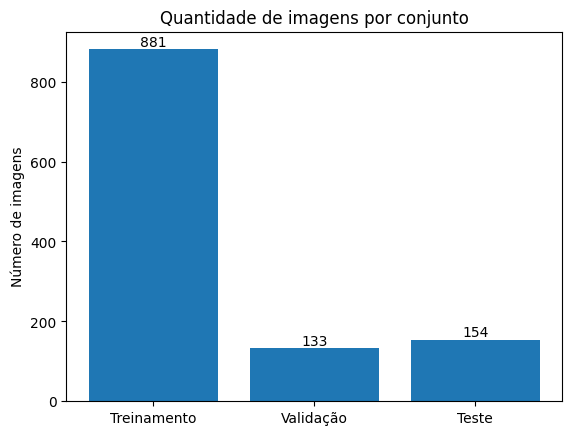

In [24]:
# Gráfico
conjuntos = ["Treinamento", "Validação", "Teste"]
quantidades = [train, validation, test]

ax = plt.bar(conjuntos, quantidades)

plt.title("Quantidade de imagens por conjunto")
plt.ylabel("Número de imagens")

for barra in ax:
    altura = barra.get_height()
    plt.text(
        barra.get_x() + barra.get_width()/2,
        altura,
        str(int(altura)),
        ha='center',
        va='bottom'
    )

plt.show()

### Integridade dos Arquivos

In [25]:
from PIL import Image
count_corrupted = 0
corrupted = list()

In [26]:
dataframe_list = list()
# 'count_corrupted' and 'corrupted' are initialized in a previous cell

for dataset_folder_name in os.listdir(root_dir):
  dataset_folder_path = os.path.join(root_dir, dataset_folder_name)

  # Ensure it's a directory (e.g., 'train', 'test', 'val') and not a file like 'val.csv' or 'classname.txt'
  if os.path.isdir(dataset_folder_path):
    for class_name_folder in os.listdir(dataset_folder_path):
      class_folder_path = os.path.join(dataset_folder_path, class_name_folder)

      # Ensure it's a directory (e.g., 'healthy', 'angular_leaf_spot', 'bean_rust')
      if os.path.isdir(class_folder_path):
        for image_filename in os.listdir(class_folder_path):
          img_path = os.path.join(class_folder_path, image_filename)

          # Ensure it's an actual file and has a dot for extension splitting
          if os.path.isfile(img_path) and '.' in image_filename:
            _, image_format = image_filename.rsplit('.', 1)
            image_format = image_format.lower()
            img = cv2.imread(img_path)

            if img is not None:
              img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
              # Converter a imagem OpenCV para uma imagem do Pillow
              img_pil = Image.fromarray(img_rgb)

              # Gerar o hash da imagem (usando perceptual hash como exemplo)
              img_hash = imagehash.phash(img_pil)
              width, height, channels = img.shape
              img_corrupted = False
            else:
              count_corrupted += 1
              corrupted.append(img_path)
              img_corrupted = True
              img_hash, image_format, width, height, channels = None, None, None, None, None

            # The 'class_name_folder' is the label for the image
            dataframe_list.append([img_path, img_corrupted, img_hash, image_format, width, height, channels, class_name_folder])

In [27]:
print(f"Total de imagens corrompidas: {count_corrupted}")

if count_corrupted > 0:
    print("\nLista de imagens corrompidas:")
    for img in corrupted:
        print(img)
else:
    print("Nenhuma imagem corrompida foi encontrada.")

Total de imagens corrompidas: 1

Lista de imagens corrompidas:
./bean-leaf-lesions-classification/train/healthy/healthy_train.120tore


In [28]:
print(corrupted)
print(len(corrupted))

['./bean-leaf-lesions-classification/train/healthy/healthy_train.120tore']
1


In [30]:
if corrupted:
    if os.path.exists(corrupted[0]):
        os.remove(corrupted[0])
    else:
        print(f"O arquivo {corrupted[0]} não foi encontrado. Pode já ter sido removido ou não existe.")
else:
    print("Nenhum arquivo corrompido para remover.")

O arquivo ./bean-leaf-lesions-classification/train/healthy/healthy_train.120tore não foi encontrado. Pode já ter sido removido ou não existe.


In [31]:
if corrupted:
    print(os.path.exists(corrupted[0]))
else:
    print("Nenhum arquivo corrompido na lista para verificar existência.")

False


In [32]:
df = pd.DataFrame(columns=['image_path', 'corrupted', 'image_hash', 'image_format', 'width', 'height', 'channels', 'label'], data = dataframe_list)

In [33]:
df.head()

,image_path,corrupted,image_hash,image_format,width,height,channels,label
0,./bean-leaf-lesions-classification/test/bean_r...,False,b82741067ce37fc1,jpg,500.0,500.0,3.0,bean_rust
1,./bean-leaf-lesions-classification/test/bean_r...,False,d243338cc3de9cc3,jpg,500.0,500.0,3.0,bean_rust
2,./bean-leaf-lesions-classification/test/bean_r...,False,d6a9ce037d146c55,jpg,500.0,500.0,3.0,bean_rust
3,./bean-leaf-lesions-classification/test/bean_r...,False,99e40b780379baab,jpg,500.0,500.0,3.0,bean_rust
4,./bean-leaf-lesions-classification/test/bean_r...,False,c1be25534ab479d8,jpg,500.0,500.0,3.0,bean_rust


#### Verificar se todas as imagens estão no mesmo formato

In [34]:
import os
from collections import Counter

root = "./bean-leaf-lesions-classification"

formatos = []

# Percorre todas as pastas do dataset
for conjunto in ["train", "val", "test"]:
    pasta_conjunto = os.path.join(root, conjunto)

    for classe in os.listdir(pasta_conjunto):
        pasta_classe = os.path.join(pasta_conjunto, classe)

        if not os.path.isdir(pasta_classe):
            continue

        for arquivo in os.listdir(pasta_classe):
            extensao = os.path.splitext(arquivo)[1].lower()
            formatos.append(extensao)

# Conta quantos arquivos existem de cada formato
contagem = Counter(formatos)

print("Formatos encontrados:")
for formato, quantidade in contagem.items():
    print(f"{formato}: {quantidade} imagens")

Formatos encontrados:
.jpg: 1167 imagens


In [35]:
# Tipos de imagens
pastas = {
    "Treinamento": "./bean-leaf-lesions-classification/train",
    "Validação": "./bean-leaf-lesions-classification/val",
    "Teste": "./bean-leaf-lesions-classification/test"
}

for nome_pasta, diretorio in pastas.items():

    formatos = {}

    for classe in os.listdir(diretorio):
        pasta_classe = os.path.join(diretorio, classe)

        if os.path.isdir(pasta_classe):
            for arquivo in os.listdir(pasta_classe):
                extensao = os.path.splitext(arquivo)[1].lower()

                if extensao in formatos:
                    formatos[extensao] += 1
                else:
                    formatos[extensao] = 1

    print(f"\n=== {nome_pasta} ===")
    for formato, quantidade in formatos.items():
        print(f"{formato}: {quantidade} imagens")


=== Treinamento ===
.jpg: 880 imagens

=== Validação ===
.jpg: 133 imagens

=== Teste ===
.jpg: 154 imagens


##### Resumo:


Foi encontrado o arquivo 'healthy_train.120tore' como corrompido e foi excluído.

Foi avaliada a estrutura do dataset

Foi realizada a separação de 15% das imagens de treinamento para teste.

Portanto ficaram 880 imagens para treinamento, 133 imagens de validação e 154 imagens para teste.

Gerado o gráfico.

Verificado se todas as imagens estão no mesmo formato


### Consistência dos Metadados

In [36]:
#Informações estatísticas dos valores de altura, largura e canais das imagens

df.describe().loc[['mean', 'std', 'min', 'max']]

,width,height,channels
mean,500.0,500.0,3.0
std,0.0,0.0,0.0
min,500.0,500.0,3.0
max,500.0,500.0,3.0


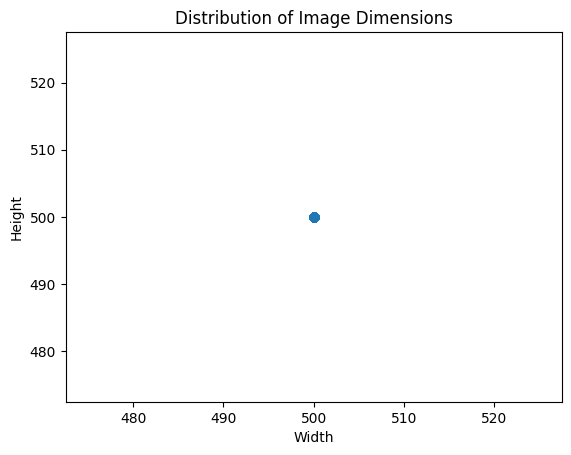

In [37]:
#Distribuição das Dimensões de Altura e Largura das Imagens

plt.scatter(df['width'], df['height'])
plt.xlabel('Width')
plt.ylabel('Height')
plt.title('Distribution of Image Dimensions')
plt.show()

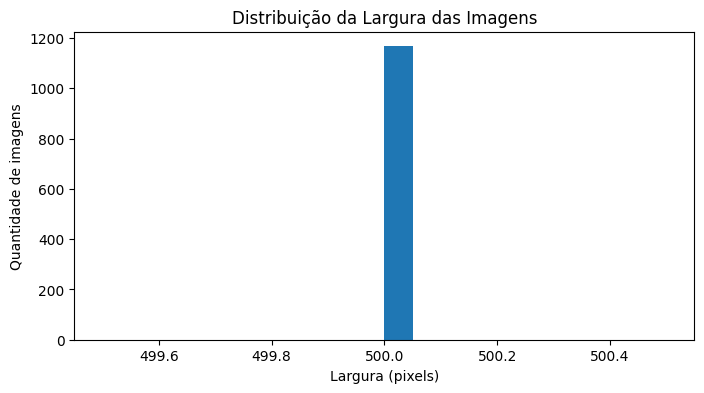

In [38]:
# Histograma da Largura
plt.figure(figsize=(8,4))
plt.hist(df['width'], bins=20)
plt.xlabel('Largura (pixels)')
plt.ylabel('Quantidade de imagens')
plt.title('Distribuição da Largura das Imagens')
plt.show()

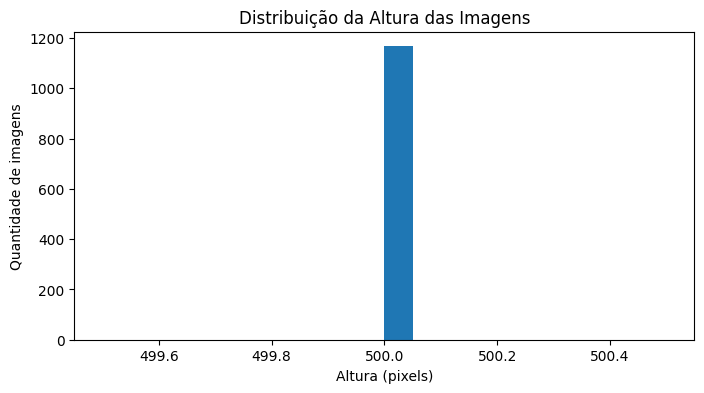

In [39]:
# Histograma da altura
plt.figure(figsize=(8,4))
plt.hist(df['height'], bins=20)
plt.xlabel('Altura (pixels)')
plt.ylabel('Quantidade de imagens')
plt.title('Distribuição da Altura das Imagens')
plt.show()

In [40]:
dimensoes = (
    df.groupby(['width', 'height'])
      .size()
      .reset_index(name='quantidade')
)

print(dimensoes)

   width  height  quantidade
0  500.0   500.0        1167


In [41]:
print(df.columns)

Index(['image_path', 'corrupted', 'image_hash', 'image_format', 'width',
       'height', 'channels', 'label'],
      dtype='object')


In [42]:
#Quantidade de informações nulas
df.isnull().sum()

,0
image_path,0
corrupted,0
image_hash,1
image_format,1
width,1
height,1
channels,1
label,0


### Qualidade das Imagens

In [43]:
#Total de imagens corrompidas

df['corrupted'].sum()

np.int64(1)

In [44]:
#Quantidade de imagens corrompidas e não corrompidas

df['corrupted'].value_counts()

,count
corrupted,
False,1167
True,1


### Distribuição das Classes

In [45]:
import os
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Configuração visual dos gráficos
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = [10, 5]

In [50]:
from pathlib import Path
import pandas as pd

# Caminho apontando para a pasta que você mostrou na imagem
pastas = {
    "Treinamento": "./bean-leaf-lesions-classification/train",
    "Validação": "./bean-leaf-lesions-classification/val",
    "Teste": "./bean-leaf-lesions-classification/test"
}


# Extensões de imagem comuns
valid_extensions = {".jpg", ".jpeg", ".png", ".bmp"}

data = []

# Varre todos os arquivos dentro da pasta archive
for split_name, folder_path_str in pastas.items():
    folder_path = Path(folder_path_str)
    for file_path in folder_path.rglob("*"):
        if file_path.is_file() and file_path.suffix.lower() in valid_extensions:
            # Captura o caminho relativo a partir do diretório base (por exemplo, train, val, test)
            # A estrutura esperada agora é: base_folder/classe/imagem.jpg
            relative_to_base = file_path.relative_to(folder_path)

            # A label é o nome da pasta da classe
            label = relative_to_base.parent.name

            data.append({"Split": split_name, "Classe": label})

# Criar o DataFrame principal
df_images = pd.DataFrame(data)

if df_images.empty:
    print("Nenhuma imagem encontrada. Verifique os caminhos e a estrutura das pastas.")
else:
    print(f"Total de imagens encontradas: {len(df_images)}")

Total de imagens encontradas: 1167


In [51]:
# Agrupa por classe e split (se houver) para contar
if df_images['Split'].nunique() > 1:
    df_dist = df_images.groupby(['Split', 'Classe']).size().reset_index(name='Quantidade')
    df_dist['Porcentagem (%)'] = (df_dist['Quantidade'] / df_dist.groupby('Split')['Quantidade'].transform('sum')) * 100
else:
    df_dist = df_images.groupby('Classe').size().reset_index(name='Quantidade')
    df_dist['Porcentagem (%)'] = (df_dist['Quantidade'] / df_dist['Quantidade'].sum()) * 100

# Exibir a tabela formatada
print("\n         Tabela de Distribuição de Classes")
print(df_dist.to_string(index=False, formatters={'Porcentagem (%)': '{:.2f}%'.format}))


         Tabela de Distribuição de Classes
      Split            Classe  Quantidade Porcentagem (%)
      Teste angular_leaf_spot          53          34.42%
      Teste         bean_rust          48          31.17%
      Teste           healthy          53          34.42%
Treinamento angular_leaf_spot         292          33.18%
Treinamento         bean_rust         300          34.09%
Treinamento           healthy         288          32.73%
  Validação angular_leaf_spot          44          33.08%
  Validação         bean_rust          45          33.83%
  Validação           healthy          44          33.08%


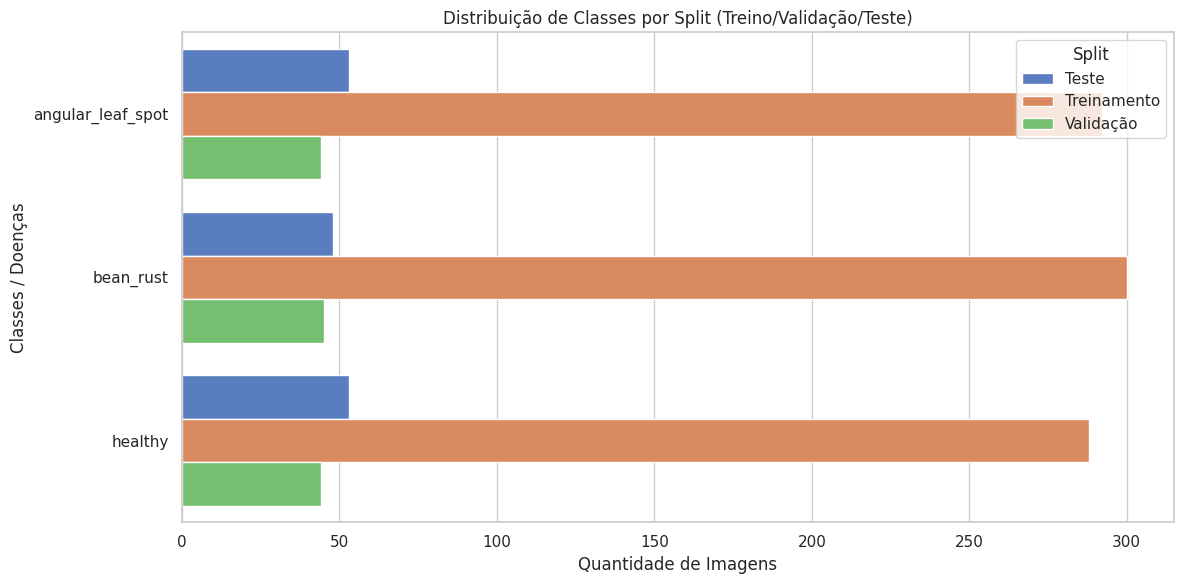

In [52]:
# Plotar o gráfico dependendo da estrutura encontrada
plt.figure(figsize=(12, 6))

if df_images['Split'].nunique() > 1:
    # Gráfico comparativo se houver divisões de treino/validação
    sns.barplot(x='Quantidade', y='Classe', hue='Split', data=df_dist, palette='muted')
    plt.title('Distribuição de Classes por Split (Treino/Validação/Teste)')
else:
    # Gráfico simples
    sns.barplot(x='Quantidade', y='Classe', data=df_dist.sort_values('Quantidade', ascending=False), palette='viridis')
    plt.title('Distribuição Geral de Classes - Lesões de Folhas de Feijão')

plt.xlabel('Quantidade de Imagens')
plt.ylabel('Classes / Doenças')
plt.tight_layout()
plt.show()

## Insights

- As três classes (angular_leaf_spot, bean_rust e healthy) estão distribuídas de forma praticamente idêntica, representando aproximadamente entre 31% e 34% do dataset cada uma. Não é preciso se preocupar com o balanceamento de dados, o modelo tem a quantidade de exemplos necessária para saber o que é uma folha saudável e o que é cada tipo de doença.

-  A Acurácia nesse projeto vai ser uma métrica extremamente confiável devido a natureza balanceada apresentada nesse dataset.



# Resumo

## O que o código faz (Passo a Passo):
- Configuração do Ambiente: Importa as bibliotecas necessárias para manipulação de arquivos (pathlib), modelagem de dados (pandas) e plotagem gráfica (matplotlib e seaborn), definindo um tema visual padronizado.

- Mapeamento Dinâmico de Arquivos: Varre a pasta alvo (archive) filtrando apenas extensões de imagem válidas (.jpg, .jpeg, .png, .bmp). Ele analisa a estrutura de pastas para extrair automaticamente o Split (Treino/Validação/Teste) e a Classe (tipo de doença ou folha saudável), organizando tudo em um DataFrame do Pandas.

- Análise Estatística da Distribuição: Agrupa os dados para calcular a quantidade absoluta de imagens e a porcentagem que cada classe representa dentro de seu respectivo split, exibindo uma tabela formatada no console.

- Visualização Gráfica: Gera um gráfico de barras horizontal comparativo utilizando o seaborn. O gráfico ilustra visualmente a distribuição das classes por split, facilitando a verificação de um possível desbalanceamento de dados.

### Duplicatas

In [63]:
import hashlib
import os
from pathlib import Path
import pandas as pd

# Caminho apontando para a pasta que você mostrou na imagem
pastas = {
     "./bean-leaf-lesions-classification"
    }


In [64]:
# Buscar arquivos CSV ou JSON no diretório
metadata_files = []
for path_str in pastas:
    folder_path = Path(path_str)
    metadata_files.extend(list(folder_path.rglob("*.csv")))
    metadata_files.extend(list(folder_path.rglob("*.json")))

if metadata_files:
    print(f" Encontrado(s) {len(metadata_files)} arquivo(s) de metadados:")
    for meta_path in metadata_files:
        print(f"\n--- Analisando: {meta_path.name} ---")
        if meta_path.suffix == '.csv':
            df_meta = pd.read_csv(meta_path)
        else:
            df_meta = pd.read_json(meta_path)

        # Total de linhas vs Linhas únicas
        total_rows = len(df_meta)
        duplicated_rows = df_meta.duplicated().sum()

        print(f"Total de registros: {total_rows}")
        print(f"Linhas exatamente duplicadas: {duplicated_rows}")

        if duplicated_rows > 0:
            print(" Exemplo de linhas duplicadas:")
            print(df_meta[df_meta.duplicated(keep=False)].head())
else:
    print(" Nenhum arquivo CSV/JSON de metadados encontrado na pasta. Prosseguindo para a verificação das imagens...")

 Encontrado(s) 2 arquivo(s) de metadados:

--- Analisando: train.csv ---
Total de registros: 1034
Linhas exatamente duplicadas: 0

--- Analisando: val.csv ---
Total de registros: 133
Linhas exatamente duplicadas: 0


In [65]:
def calculate_md5(file_path, chunk_size=8192):
    """Calcula o hash MD5 de um arquivo lendo em partes (eficiente em memória)."""
    hasher = hashlib.md5()
    with open(file_path, 'rb') as f:
        while chunk := f.read(chunk_size):
            hasher.update(chunk)
    return hasher.hexdigest()
valid_extensions = {".jpg", ".jpeg", ".png", ".bmp"}
image_records = []

print(" Mapeando e gerando hashes de todas as imagens...")

for path_str in pastas:
    base_folder_path = Path(path_str)
    for file_path in base_folder_path.rglob("*"):
        if file_path.is_file() and file_path.suffix.lower() in valid_extensions:
            # Determine the relative path to extract split and label
            # We need to reconstruct the relative path from the *first* folder after the base_folder_path
            # For example, if base_folder_path is 'train' and file_path is 'train/healthy/image.jpg'
            # relative_parts should start from 'healthy'

            relative_to_base = file_path.relative_to(base_folder_path)
            parts = relative_to_base.parts

            # Assuming structure: base_folder_path/classe/imagem.jpg
            # If there's only one part, it means it's directly in the base_folder_path, which is unlikely for class labels
            if len(parts) >= 1:
                label = parts[0] # The first subfolder is typically the class
            else:
                label = "unknown" # Fallback if no class folder is found

            # In this context, 'pastas' holds only training data, so 'split' can be hardcoded or inferred if structure allows.
            # For now, let's assume if it's in 'train', split is 'Treinamento'.
            split = "Treinamento" # Adjust if 'pastas' can contain other splits

            # Generates the MD5 hash of the image content
            file_hash = calculate_md5(file_path)

            image_records.append({
                "filename": file_path.name,
                "path": str(file_path),
                "split": split,
                "classe": label,
                "hash_md5": file_hash
            })

df_hashes = pd.DataFrame(image_records)
print(f" Concluído! {len(df_hashes)} imagens processadas.")

 Mapeando e gerando hashes de todas as imagens...
 Concluído! 1167 imagens processadas.


In [66]:
# Identificar hashes que aparecem mais de uma vez
duplicate_hashes = df_hashes[df_hashes.duplicated(subset=['hash_md5'], keep=False)]

if duplicate_hashes.empty:
    print("NENHUMA DUPLICATA ENCONTRADA! O dataset está 100% limpo quanto a conteúdos idênticos.")
else:
    total_duplicadas = duplicate_hashes['hash_md5'].nunique()
    print(f"Foram encontradas imagens duplicadas associadas a {total_duplicadas} hashes diferentes.\n")

    # 1. Checar se há VAZAMENTO DE DADOS (Data Leakage) entre Train e Val
    leakage_df = duplicate_hashes.groupby('hash_md5')['split'].nunique()
    hashes_vazados = leakage_df[leakage_df > 1].index

    if len(hashes_vazados) > 0:
        print(f"ALERTA CRÍTICO DE DATA LEAKAGE!")
        print(f"Existem {len(hashes_vazados)} imagem(ns) idêntica(s) presentes TANTO no Treino QUANTO na Validação.\n")
        print("Exemplos de imagens com vazamento:")
        display(duplicate_hashes[duplicate_hashes['hash_md5'].isin(hashes_vazados)][['filename', 'split', 'classe', 'hash_md5']].head(10))
    else:
        print("Sem Data Leakage: As duplicatas existem, mas não estão cruzando a fronteira de treino/validação.")

    # 2. Exibir tabela resumo de todas as duplicatas
    print("\n--- Tabela Completa de Arquivos Duplicados ---")
    display(duplicate_hashes.sort_values(by='hash_md5')[['filename', 'split', 'classe', 'hash_md5']])

NENHUMA DUPLICATA ENCONTRADA! O dataset está 100% limpo quanto a conteúdos idênticos.


### Informações complementares
Elaborar uma apresentação para mostrar os resultados.

Apresentar o dataset de forma detalhada.

Verifique quais itens em Informações esperadas podem ser aplicados no dataset.

### ATIVIDADE-04-ETAPA-02

#### Objetivo: Apresentar métodos da literatura e propor ideias para métodos próprios.



### Métodos da literatura

#### Notebook executado

https://www.kaggle.com/code/akhilchibber/bean-leaf-lesions-classification#The-Dataset

### Métodos próprios

#### Apresentar ideias que podem melhorar os métodos encontrados e testados da literatura.

- O notebook analisado não realizou a separação das imagens para teste, portanto sugerimos a separação de uma parte das imagens de treinamento como melhoria;

- O notebook não realizou a análise exploratória dos dados, portanto, a imagem corrompida não foi excluída do dataset;



#### Ideias para melhorar uma técnica

Otimização de Hiperparâmetros - alterar ou reduzir os hiperparâmetros.

Elaborar uma nova arquitetura mais leve para que o treino e o teste sejam rápidos.

Reduzir número de imagens no treinamento e manter o desempenho.

### Informações complementares

Elaborar uma apresentação para mostrar os métodos da literatura e próprios.

### ATIVIDADE-04-ETAPA-03

#### Objetivo

Apresentar métodos da literatura e métodos próprios.

### Metodologia

### Resultados

### Conclusões